In [1]:
import pandas as pd
from textblob import TextBlob
from sklearn.metrics import classification_report
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


In [2]:
search_area = os.path.dirname(os.getcwd())      # Step up one level from wherever Jupyter's directory is currently active.
csv_path = None
for root, dirs, files in os.walk(search_area):  # Scan all nearby folders for the file

    for file in files:
        if file.lower() == 'steam.csv':         # Checks for 'steam.csv' 
            csv_path = os.path.join(root, file)
            break
    if csv_path:
        break


if csv_path:    # Load the dataset when found
    df = pd.read_csv(csv_path)

In [3]:
df.head()

,title,rating,review
0,Can't access the games I paid for,1,I opened tickets HT-2FQ9-CY9F-355R and HT-VJ6D...
1,"Great Service, they deserve a monopoly.",5,This must be at least 10 characters.
2,There is no service,1,There is no service. There is no help. There i...
3,I used Steam for years gaming on a PC…,2,I used Steam for years gaming on a PC until th...
4,I was forced to download Steam to log…,1,I was forced to download Steam to log into S&b...


In [4]:
df.info() # Check for missing values and data types

<class 'pandas.DataFrame'>
RangeIndex: 2374 entries, 0 to 2373
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   title   2374 non-null   str  
 1   rating  2374 non-null   int64
 2   review  2374 non-null   str  
dtypes: int64(1), str(2)
memory usage: 55.8 KB


In [5]:
df['rating'].value_counts() # Check rating distribution

rating
1    1626
5     443
4     117
2     113
3      75
Name: count, dtype: int64

In [6]:
df['rating_sentiment'] = df['rating'].map({1:'negative',2:'negative',3:'neutral',4:'positive',5:'positive'})  # Map ratings to sentiment categories

In [7]:
df.head()

,title,rating,review,rating_sentiment
0,Can't access the games I paid for,1,I opened tickets HT-2FQ9-CY9F-355R and HT-VJ6D...,negative
1,"Great Service, they deserve a monopoly.",5,This must be at least 10 characters.,positive
2,There is no service,1,There is no service. There is no help. There i...,negative
3,I used Steam for years gaming on a PC…,2,I used Steam for years gaming on a PC until th...,negative
4,I was forced to download Steam to log…,1,I was forced to download Steam to log into S&b...,negative


In [8]:
df['rating_sentiment'].value_counts() # Check distribution of sentiment categories

rating_sentiment
negative    1739
positive     560
neutral       75
Name: count, dtype: int64

# TextBlob Sentimental Analysis:

In [9]:
df['predicted_sentiment'] = df['review'].apply(lambda review: TextBlob(review).sentiment.polarity) # Get polarity scores for each review

In [10]:
df.head()

,title,rating,review,rating_sentiment,predicted_sentiment
0,Can't access the games I paid for,1,I opened tickets HT-2FQ9-CY9F-355R and HT-VJ6D...,negative,-0.360000
1,"Great Service, they deserve a monopoly.",5,This must be at least 10 characters.,positive,-0.300000
2,There is no service,1,There is no service. There is no help. There i...,negative,-0.433333
3,I used Steam for years gaming on a PC…,2,I used Steam for years gaming on a PC until th...,negative,-0.036029
4,I was forced to download Steam to log…,1,I was forced to download Steam to log into S&b...,negative,-0.045139


In [11]:
df['polarity'] = df['predicted_sentiment'] # Classify polarity scores into sentiment categories

In [12]:
df.head()

,title,rating,review,rating_sentiment,predicted_sentiment,polarity
0,Can't access the games I paid for,1,I opened tickets HT-2FQ9-CY9F-355R and HT-VJ6D...,negative,-0.360000,-0.360000
1,"Great Service, they deserve a monopoly.",5,This must be at least 10 characters.,positive,-0.300000,-0.300000
2,There is no service,1,There is no service. There is no help. There i...,negative,-0.433333,-0.433333
3,I used Steam for years gaming on a PC…,2,I used Steam for years gaming on a PC until th...,negative,-0.036029,-0.036029
4,I was forced to download Steam to log…,1,I was forced to download Steam to log into S&b...,negative,-0.045139,-0.045139


In [13]:
df['predicted_sentiment'] = df['predicted_sentiment'].apply(lambda p: 'positive' if p>0.1 else ('negative') if p<-0.1 else 'neutral') # Classify polarity scores into sentiment categories with thresholds

In [14]:
textblob_accuracy = (df['rating_sentiment'] == df['predicted_sentiment']).mean() # Calculate accuracy by comparing predicted sentiment to actual sentiment

In [15]:
textblob_accuracy 

np.float64(0.5067396798652064)

In [16]:
df['predicted_sentiment'].value_counts() # Checks distribution of predicted sentiment categories

predicted_sentiment
neutral     876
negative    816
positive    682
Name: count, dtype: int64

In [17]:
# Compares the actual ratings vs. TextBlob's guesses
actual_labels = df['rating_sentiment']
predicted_labels = df['predicted_sentiment']

In [18]:
# Generates and prints the full performance metrics report 
report = classification_report(actual_labels, predicted_labels)
print(report)

              precision    recall  f1-score   support

    negative       0.94      0.44      0.60      1739
     neutral       0.04      0.43      0.07        75
    positive       0.59      0.71      0.64       560

    accuracy                           0.51      2374
   macro avg       0.52      0.53      0.44      2374
weighted avg       0.83      0.51      0.60      2374



# Plots

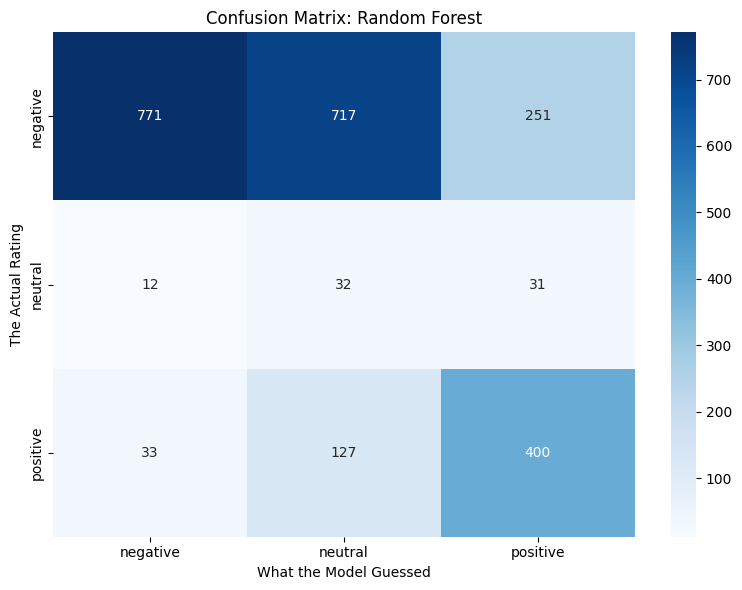

In [19]:
# Generate comfusion matrix
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(actual_labels, predicted_labels, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('What the Model Guessed')
plt.ylabel('The Actual Rating')
plt.tight_layout()
plt.show()

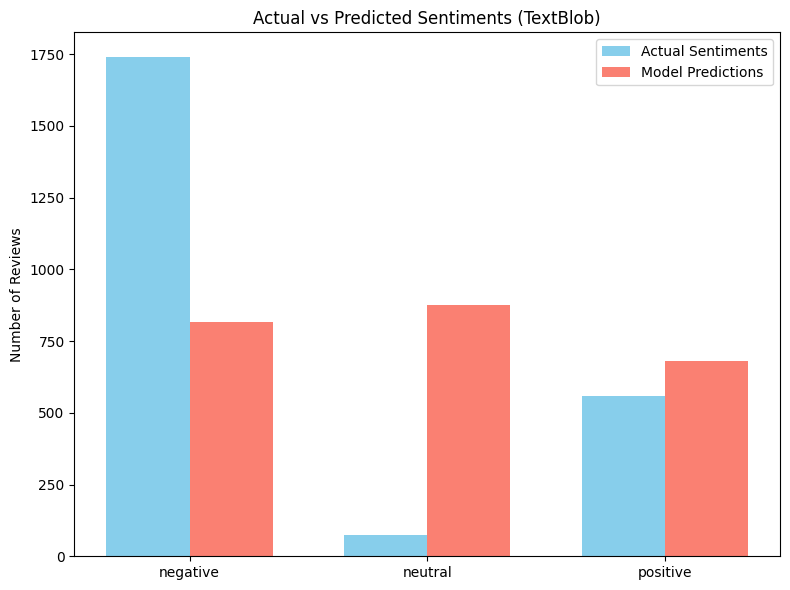

In [20]:
# Actual vs. Predicted Distribution
labels = ['negative', 'neutral', 'positive']

actual_counts = actual_labels.value_counts().reindex(labels, fill_value=0)
predicted_counts = pd.Series(predicted_labels).value_counts().reindex(labels, fill_value=0)

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, actual_counts, width, label='Actual Sentiments', color='skyblue')
ax.bar(x + width/2, predicted_counts, width, label='Model Predictions', color='salmon')

ax.set_ylabel('Number of Reviews')
ax.set_title('Actual vs Predicted Sentiments (TextBlob)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\aggel\AppData\Local\Temp\ipykernel_14808\2619722613.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x=df['rating'], y=df['polarity'], palette='coolwarm', jitter=True, alpha=0.6)


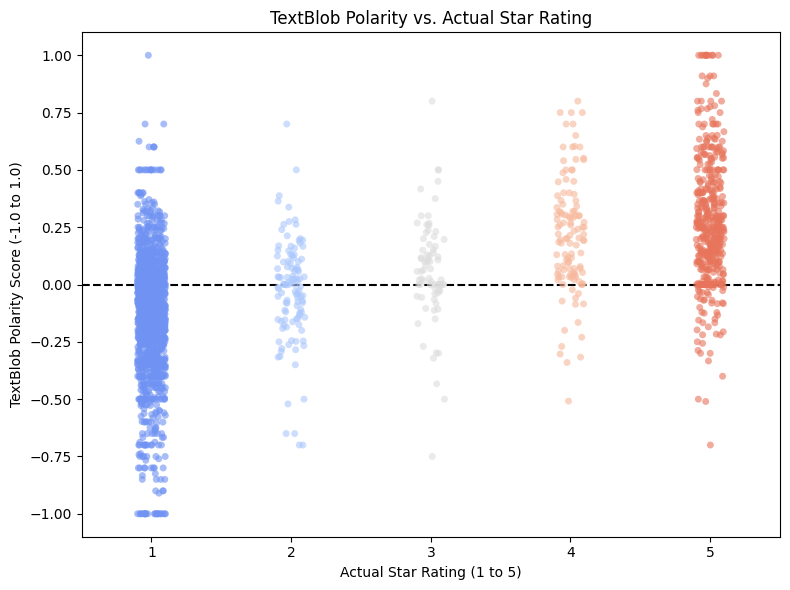

In [21]:
plt.figure(figsize=(8, 6))
sns.stripplot(x=df['rating'], y=df['polarity'], palette='coolwarm', jitter=True, alpha=0.6)

plt.title('TextBlob Polarity vs. Actual Star Rating')
plt.xlabel('Actual Star Rating (1 to 5)')
plt.ylabel('TextBlob Polarity Score (-1.0 to 1.0)')
plt.axhline(0, color='black', linestyle='--') # Adds a line at 0 (Neutral)

plt.tight_layout()
plt.show()
